In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree
from sklearn.metrics import (mean_squared_error, root_mean_squared_error, mean_absolute_error,
                             accuracy_score, confusion_matrix, precision_score,
                             recall_score, f1_score, roc_curve, roc_auc_score)   # ← вот это важно!

pd.set_option('display.max_columns', 100)
sns.set_style('whitegrid')
%matplotlib inline

In [4]:
df = pd.read_csv('spotify_artist_streaming_2020_2025.csv')
print("Размер исходного датасета:", df.shape)
df.head()

Размер исходного датасета: (50000, 33)


,track_id,track_name,artist_name,album_name,release_date,genre,duration_ms,popularity,danceability,energy,key,loudness,mode,instrumentalness,tempo,stream_count,country,explicit,label,release_year,release_month,release_day_of_week,duration_minutes,popularity_category,loudness_category,key_name,mode_name,is_explicit_bool,release_quarter,is_weekend_release,log_stream_count,upbeat_score,artist_track_count
0,346d85e2-ffde-41b3-854a-589ed880b91f,Storm,Ethereal,The Hollow Journeys,2021-10-06,Pop,169594,47,0.6777,0.7949,9,-2.90,1,0.0065,111.89,46592,US,False,Self-Released,2021,10,Wednesday,2.83,Medium,Loud,A,Major,False,Q4,False,10.7492,0.6632,3232
1,12bc268a-363b-4f19-8fa8-0ced7ae1e462,Silent,The Wolfs,Ancient Thunder,2024-10-26,K-Pop,256755,26,0.9405,0.7163,1,-7.72,1,0.0198,129.17,5374,ES,False,Prism Audio,2024,10,Saturday,4.28,Medium,Moderate,C#,Major,False,Q4,True,8.5895,0.7615,20
2,30d627d9-878d-4bb3-be59-71feb6ed4f3f,Shattered Lines,LolaOre,Twisted Harbors,2022-11-12,Punk,170212,46,0.6853,0.9500,4,-2.38,1,0.0103,150.06,218262,US,False,Columbia Records,2022,11,Saturday,2.84,Medium,Loud,E,Major,False,Q4,True,12.2935,0.7828,199
3,85501bb9-d221-4339-9e2e-29b1b3daff0a,Breaking Roses,Clay Black,The Blinding Letters,2020-06-22,Pop,181250,4,0.7817,0.6943,6,-8.00,1,0.0151,121.16,5248,ZA,False,Midnight Records,2020,6,Monday,3.02,Low,Moderate,F#,Major,False,Q2,False,8.5658,0.6778,693
4,7bf92bd2-c6fe-4869-a90e-242bb8bbe7a3,Lines,Knot Hart,The Cosmic Letters,2024-01-22,Latin,160894,27,0.7200,0.4958,1,-6.38,1,0.0372,104.16,27420,US,False,Catalyst Records,2024,1,Monday,2.68,Medium,Moderate,C#,Major,False,Q1,False,10.2191,0.5494,12111


In [5]:
print("Всего пропусков:", df.isnull().sum().sum())
print("Количество колонок:", df.shape[1])
print("\nКолонки:")
print(df.columns.tolist())
print("\nТипы данных:")
print(df.dtypes.value_counts())

Всего пропусков: 0
Количество колонок: 33

Колонки:
['track_id', 'track_name', 'artist_name', 'album_name', 'release_date', 'genre', 'duration_ms', 'popularity', 'danceability', 'energy', 'key', 'loudness', 'mode', 'instrumentalness', 'tempo', 'stream_count', 'country', 'explicit', 'label', 'release_year', 'release_month', 'release_day_of_week', 'duration_minutes', 'popularity_category', 'loudness_category', 'key_name', 'mode_name', 'is_explicit_bool', 'release_quarter', 'is_weekend_release', 'log_stream_count', 'upbeat_score', 'artist_track_count']

Типы данных:
str        14
int64       8
float64     8
bool        3
Name: count, dtype: int64


In [6]:
# 1) Дублируем датасет, чтобы не портить исходный
df_clean = df.copy()

# 2) Кодируем категориальные признаки (one-hot)
categorical_cols = ['genre', 'country', 'key_name', 'mode_name',
                    'label', 'release_day_of_week', 'release_quarter',
                    'loudness_category']

df_clean = pd.get_dummies(df_clean, columns=categorical_cols,
                          drop_first=True, dtype=int)

print("Размер после one-hot:", df_clean.shape)

Размер после one-hot: (50000, 125)


In [7]:
y = df_clean['popularity']

columns_to_drop = ['popularity', 'track_id', 'track_name', 'artist_name', 'album_name','release_date', 'popularity_category', 'stream_count', 'log_stream_count']

X = df_clean.drop(columns=columns_to_drop)

# Проверяем, что не осталось строковых колонок
string_cols = X.select_dtypes(include=['object']).columns.tolist()
print("Строковые колонки в X:", string_cols)
print("Размер X:", X.shape)
print("Размер y:", y.shape)

Строковые колонки в X: []
Размер X: (50000, 116)
Размер y: (50000,)


In [8]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Train: {X_train.shape}, Test: {X_test.shape}, Val: {X_val.shape}")

Train: (35000, 116), Test: (7500, 116), Val: (7500, 116)


In [9]:
dt_reg = DecisionTreeRegressor(random_state=42)
dt_reg.fit(X_train, y_train)

y_pred_dt = dt_reg.predict(X_test)

mse_dt  = mean_squared_error(y_test, y_pred_dt)
rmse_dt = root_mean_squared_error(y_test, y_pred_dt)
mae_dt  = mean_absolute_error(y_test, y_pred_dt)

print("Decision Tree Regressor (без ограничений):")
print(f"MSE:  {mse_dt:.4f}")
print(f"RMSE: {rmse_dt:.4f}")
print(f"MAE:  {mae_dt:.4f}")

Decision Tree Regressor (без ограничений):
MSE:  499.6116
RMSE: 22.3520
MAE:  17.7959


In [11]:
y_pred_train = dt_reg.predict(X_train)

rmse_train = root_mean_squared_error(y_train, y_pred_train)
rmse_test  = root_mean_squared_error(y_test,  y_pred_dt)

print(f"RMSE на train: {rmse_train:.4f}")
print(f"RMSE на test:  {rmse_test:.4f}")
print(f"Разница:       {rmse_test - rmse_train:.4f}")
print("Ratio: деление на ноль — модель идеально запомнила train (переобучение)")

RMSE на train: 0.0000
RMSE на test:  22.3520
Разница:       22.3520
Ratio: деление на ноль — модель идеально запомнила train (переобучение)


In [12]:
dt_reg_limited = DecisionTreeRegressor(max_depth=4, random_state=42)
dt_reg_limited.fit(X_train, y_train)

y_pred_train_lim = dt_reg_limited.predict(X_train)
y_pred_test_lim  = dt_reg_limited.predict(X_test)

rmse_train_lim = root_mean_squared_error(y_train, y_pred_train_lim)
rmse_test_lim  = root_mean_squared_error(y_test,  y_pred_test_lim)
mae_test_lim   = mean_absolute_error(y_test,   y_pred_test_lim)

print("Decision Tree Regressor (max_depth=4):")
print(f"RMSE train: {rmse_train_lim:.4f}")
print(f"RMSE test:  {rmse_test_lim:.4f}")
print(f"MAE test:   {mae_test_lim:.4f}")
print(f"Отношение test/train: {rmse_test_lim / rmse_train_lim:.2f}")

Decision Tree Regressor (max_depth=4):
RMSE train: 15.8218
RMSE test:  15.8146
MAE test:   12.8589
Отношение test/train: 1.00


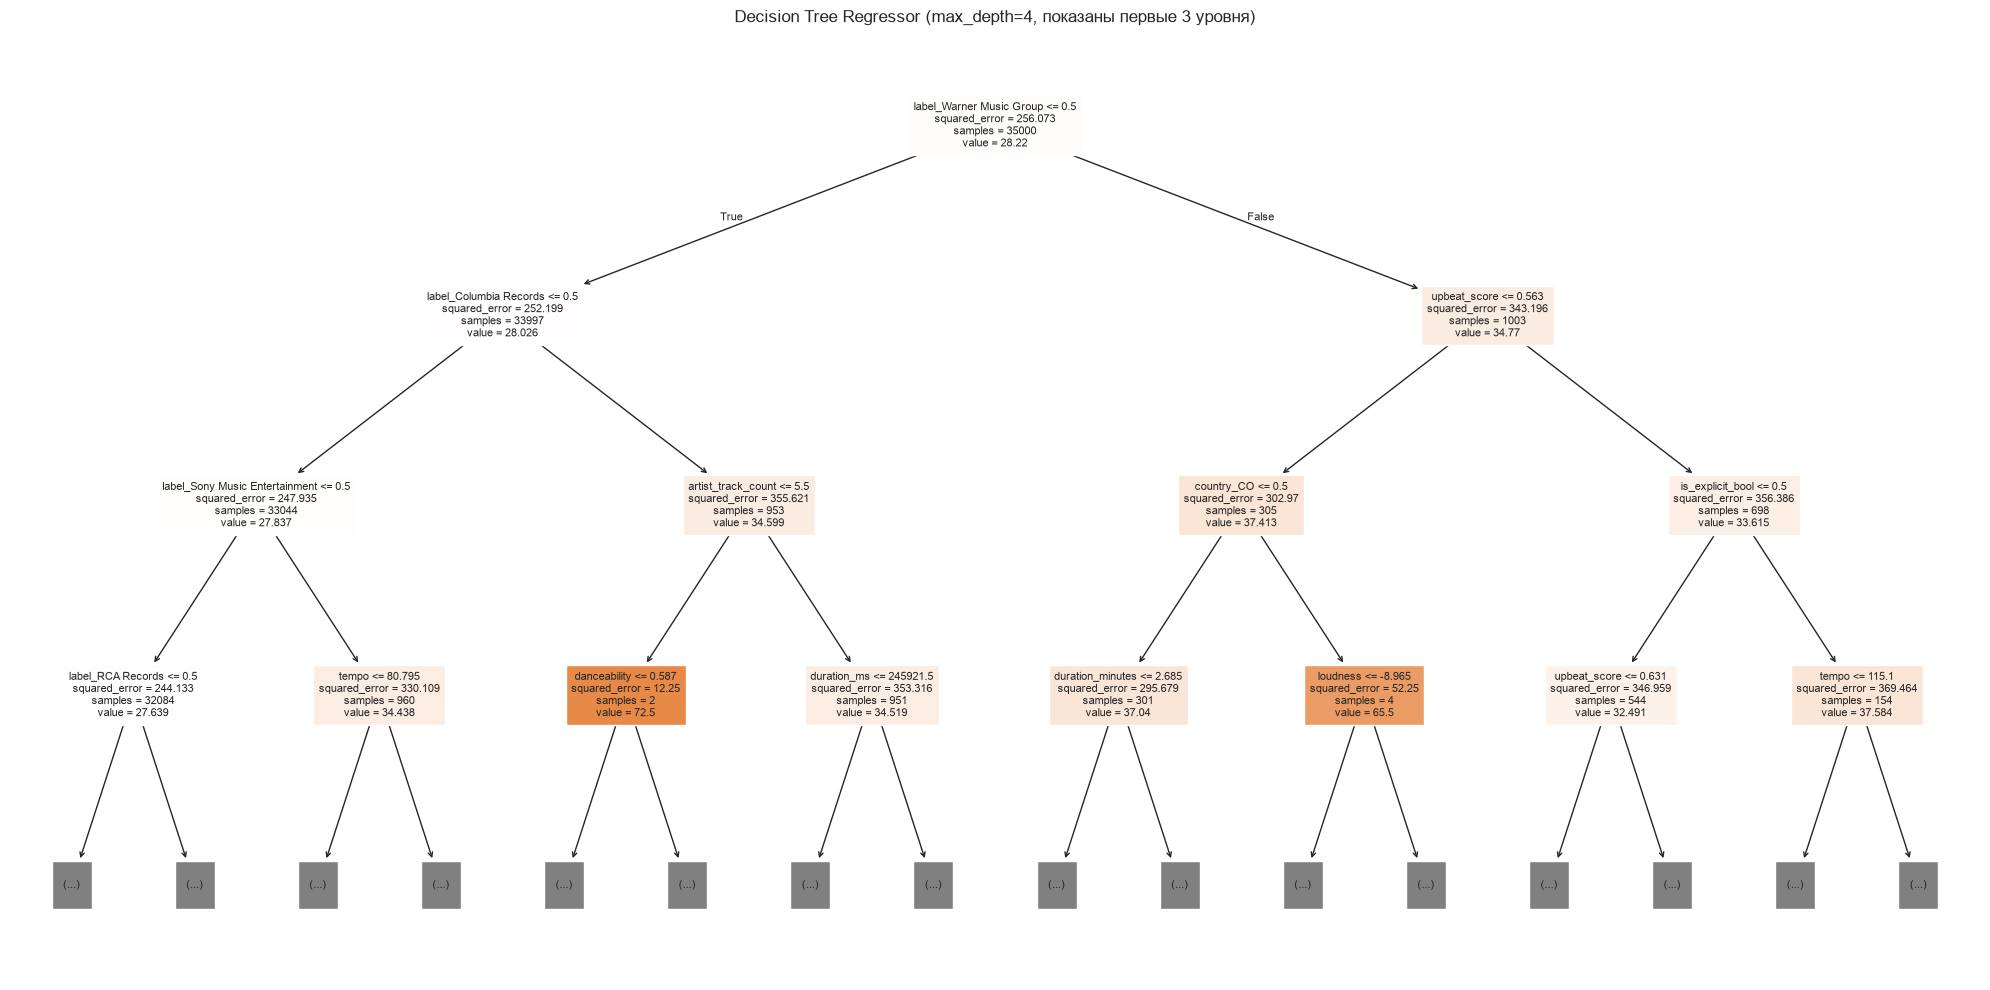

In [13]:
plt.figure(figsize=(20, 10))
plot_tree(
    dt_reg_limited,
    feature_names=X.columns,
    filled=True,
    max_depth=3,
    fontsize=8
)
plt.title('Decision Tree Regressor (max_depth=4, показаны первые 3 уровня)')
plt.tight_layout()
plt.show()

In [14]:
depths = [1, 2, 3, 4, 5, 6, 7, 10, 15, 20, None]
results_depth = []

for d in depths:
    model = DecisionTreeRegressor(max_depth=d, random_state=42)
    model.fit(X_train, y_train)
    
    rmse_tr = root_mean_squared_error(y_train, model.predict(X_train))
    rmse_va = root_mean_squared_error(y_val,   model.predict(X_val))
    rmse_te = root_mean_squared_error(y_test,  model.predict(X_test))
    
    results_depth.append({
        'max_depth':   d,
        'RMSE_train':  round(rmse_tr, 4),
        'RMSE_val':    round(rmse_va, 4),
        'RMSE_test':   round(rmse_te, 4),
        'ratio_val/train': round(rmse_va / rmse_tr, 2) if rmse_tr > 0 else float('inf')
    })

df_depth = pd.DataFrame(results_depth)
print(df_depth.to_string(index=False))

 max_depth  RMSE_train  RMSE_val  RMSE_test  ratio_val/train
       1.0     15.9627   16.0532    15.8827             1.01
       2.0     15.9220   16.0399    15.8651             1.01
       3.0     15.8750   16.0219    15.8508             1.01
       4.0     15.8218   15.9961    15.8146             1.01
       5.0     15.7530   15.9913    15.8181             1.02
       6.0     15.6683   16.0226    15.8140             1.02
       7.0     15.5689   16.0271    15.8468             1.03
      10.0     15.1639   16.2102    15.9468             1.07
      15.0     14.2269   16.9104    16.6298             1.19
      20.0     12.9260   17.7729    17.6246             1.37
       NaN      0.0000   22.2178    22.3520              inf


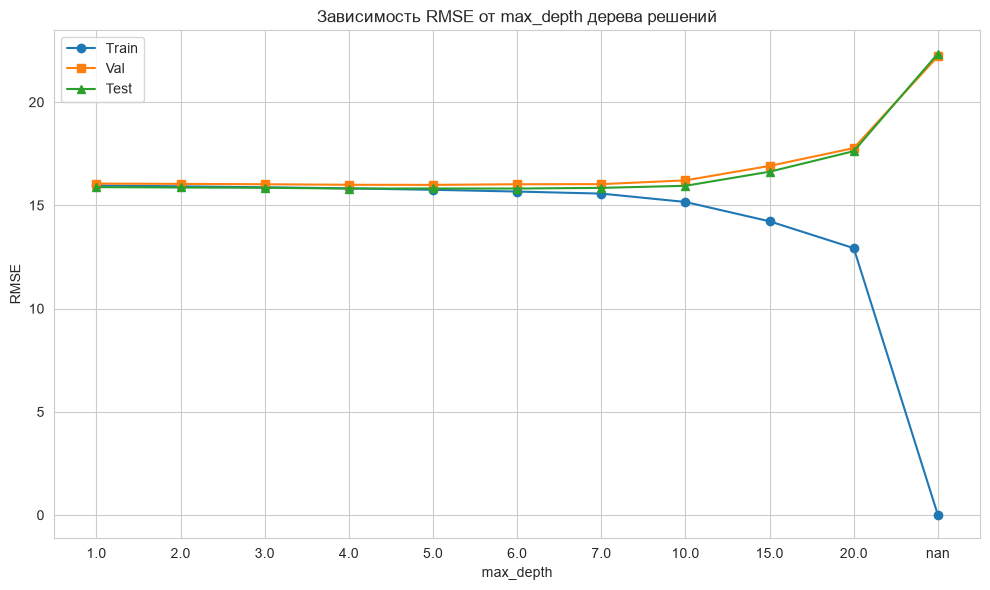

In [16]:
# Готовим данные для графика
labels = [str(d) for d in df_depth['max_depth']]  # None → "None"

plt.figure(figsize=(10, 6))
plt.plot(labels, df_depth['RMSE_train'].values, 'o-', label='Train')
plt.plot(labels, df_depth['RMSE_val'].values,   's-', label='Val')
plt.plot(labels, df_depth['RMSE_test'].values,  '^-', label='Test')
plt.xlabel('max_depth')
plt.ylabel('RMSE')
plt.title('Зависимость RMSE от max_depth дерева решений')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [17]:
# Оптимальная глубина по валидации
best_depth = int(df_depth.loc[df_depth['RMSE_val'].idxmin(), 'max_depth'])
print(f"Оптимальная глубина по валидации: max_depth={best_depth}")

# Обучаем финальную модель
dt_reg_best = DecisionTreeRegressor(max_depth=best_depth, random_state=42)
dt_reg_best.fit(X_train, y_train)

# Предсказания и метрики
y_pred_best = dt_reg_best.predict(X_test)

print(f"\nФинальная модель (max_depth={best_depth}):")
print(f"RMSE test: {root_mean_squared_error(y_test, y_pred_best):.4f}")
print(f"MAE  test: {mean_absolute_error(y_test, y_pred_best):.4f}")

Оптимальная глубина по валидации: max_depth=5

Финальная модель (max_depth=5):
RMSE test: 15.8181
MAE  test: 12.8439


In [18]:
summary = pd.DataFrame({
    'Модель': [
        'DTree (без ограничений)',
        'DTree (max_depth=4)',
        f'DTree (max_depth={best_depth}, оптимум по val)',
    ],
    'RMSE_train': [
        root_mean_squared_error(y_train, dt_reg.predict(X_train)),
        rmse_train_lim,
        root_mean_squared_error(y_train, dt_reg_best.predict(X_train)),
    ],
    'RMSE_test': [
        rmse_dt,
        rmse_test_lim,
        root_mean_squared_error(y_test, y_pred_best),
    ],
    'MAE_test': [
        mae_dt,
        mae_test_lim,
        mean_absolute_error(y_test, y_pred_best),
    ],
})

summary['ratio_test/train'] = summary['RMSE_test'] / summary['RMSE_train']
print(summary.to_string(index=False))

                             Модель  RMSE_train  RMSE_test  MAE_test  ratio_test/train
            DTree (без ограничений)    0.000000  22.351993 17.795867               inf
                DTree (max_depth=4)   15.821830  15.814637 12.858872          0.999545
DTree (max_depth=5, оптимум по val)   15.753032  15.818086 12.843881          1.004130


In [19]:
y_class = df_clean['is_explicit_bool']

columns_to_drop_class = columns_to_drop + ['explicit', 'is_explicit_bool']
X_class = df_clean.drop(columns=columns_to_drop_class)

print("Строковые колонки:", X_class.select_dtypes(include=['object']).columns.tolist())
print("Размер X_class:", X_class.shape)
print("\nРаспределение классов:")
print(y_class.value_counts(normalize=True))

Строковые колонки: []
Размер X_class: (50000, 114)

Распределение классов:
is_explicit_bool
False    0.75152
True     0.24848
Name: proportion, dtype: float64


In [20]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class, y_class, test_size=0.3, random_state=42, stratify=y_class
)

print(f"Train: {X_train_c.shape}")
print(f"Test:  {X_test_c.shape}")
print("\nРаспределение в train:")
print(y_train_c.value_counts(normalize=True))
print("\nРаспределение в test:")
print(y_test_c.value_counts(normalize=True))

Train: (35000, 114)
Test:  (15000, 114)

Распределение в train:
is_explicit_bool
False    0.751514
True     0.248486
Name: proportion, dtype: float64

Распределение в test:
is_explicit_bool
False    0.751533
True     0.248467
Name: proportion, dtype: float64


In [21]:
dt_clf = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_clf.fit(X_train_c, y_train_c)

y_pred_clf = dt_clf.predict(X_test_c)

print("DecisionTreeClassifier (max_depth=5):")
print(f"Accuracy:  {accuracy_score(y_test_c, y_pred_clf):.4f}")
print(f"Precision: {precision_score(y_test_c, y_pred_clf):.4f}")
print(f"Recall:    {recall_score(y_test_c, y_pred_clf):.4f}")
print(f"F1-score:  {f1_score(y_test_c, y_pred_clf):.4f}")

DecisionTreeClassifier (max_depth=5):
Accuracy:  0.7516
Precision: 0.5556
Recall:    0.0013
F1-score:  0.0027


Confusion Matrix:
[[11269     4]
 [ 3722     5]]


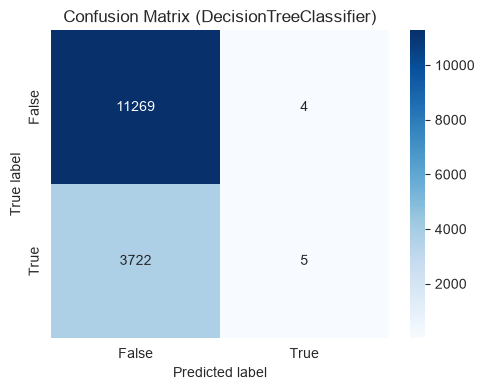

In [22]:
cm_dt = confusion_matrix(y_test_c, y_pred_clf)
print("Confusion Matrix:")
print(cm_dt)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues',
            xticklabels=['False', 'True'],
            yticklabels=['False', 'True'])
plt.title('Confusion Matrix (DecisionTreeClassifier)')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()

In [23]:
y_proba = dt_clf.predict_proba(X_test_c)

print("Классы модели:", dt_clf.classes_)
print("Форма y_proba:", y_proba.shape)
print("\nПервые 5 строк y_proba (вероятности для [False, True]):")
print(y_proba[:5])

# Вероятности для положительного класса (True)
y_proba_pos = y_proba[:, 1]
print("\nПервые 5 вероятностей класса True:")
print(y_proba_pos[:5])

Классы модели: [False  True]
Форма y_proba: (15000, 2)

Первые 5 строк y_proba (вероятности для [False, True]):
[[0.76564203 0.23435797]
 [0.74014543 0.25985457]
 [0.74651043 0.25348957]
 [0.74014543 0.25985457]
 [0.74651043 0.25348957]]

Первые 5 вероятностей класса True:
[0.23435797 0.25985457 0.25348957 0.25985457 0.25348957]


AUC (Area Under Curve) = 0.5035


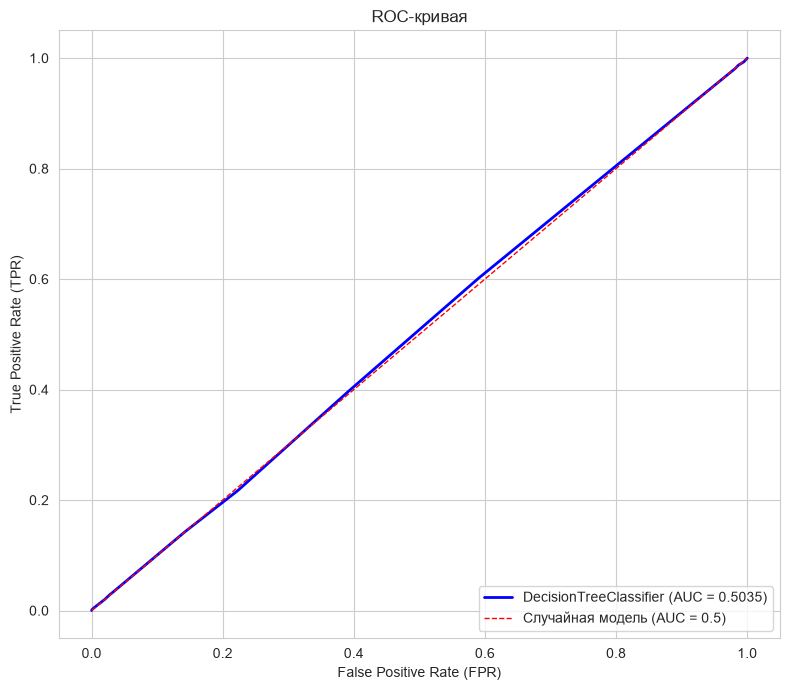

In [26]:
# Считаем ROC-кривую
fpr, tpr, thresholds = roc_curve(y_test_c, y_proba_pos)
auc_score = roc_auc_score(y_test_c, y_proba_pos)

print(f"AUC (Area Under Curve) = {auc_score:.4f}")

# Строим график
plt.figure(figsize=(8, 7))
plt.plot(fpr, tpr, 'b-', linewidth=2, label=f'DecisionTreeClassifier (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], 'r--', linewidth=1, label='Случайная модель (AUC = 0.5)')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC-кривая')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

In [27]:
dt_clf_bal = DecisionTreeClassifier(
    max_depth=5,
    random_state=42,
    class_weight='balanced'   # ← ключевое отличие
)
dt_clf_bal.fit(X_train_c, y_train_c)

y_pred_bal  = dt_clf_bal.predict(X_test_c)
y_proba_bal = dt_clf_bal.predict_proba(X_test_c)[:, 1]

print("DecisionTreeClassifier (max_depth=5, balanced):")
print(f"Accuracy:  {accuracy_score(y_test_c, y_pred_bal):.4f}")
print(f"Precision: {precision_score(y_test_c, y_pred_bal):.4f}")
print(f"Recall:    {recall_score(y_test_c, y_pred_bal):.4f}")
print(f"F1-score:  {f1_score(y_test_c, y_pred_bal):.4f}")
print("\nConfusion Matrix (balanced):")
print(confusion_matrix(y_test_c, y_pred_bal))

DecisionTreeClassifier (max_depth=5, balanced):
Accuracy:  0.6092
Precision: 0.2405
Recall:    0.2654
F1-score:  0.2523

Confusion Matrix (balanced):
[[8149 3124]
 [2738  989]]


AUC без баланса: 0.5035
AUC с балансом:  0.4985


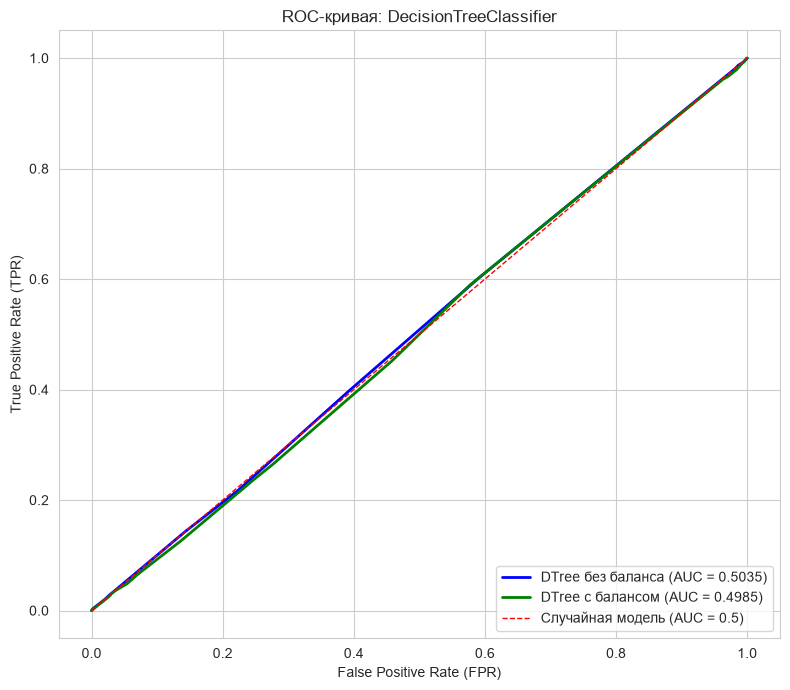

In [29]:
# Без баланса — используем y_proba_pos (посчитан в ячейке 17)
# С балансом — используем y_proba_bal (посчитан в ячейке 15.5)

fpr,     tpr,     _ = roc_curve(y_test_c, y_proba_pos)
fpr_bal, tpr_bal, _ = roc_curve(y_test_c, y_proba_bal)

auc_score = roc_auc_score(y_test_c, y_proba_pos)
auc_bal   = roc_auc_score(y_test_c, y_proba_bal)

print(f"AUC без баланса: {auc_score:.4f}")
print(f"AUC с балансом:  {auc_bal:.4f}")

plt.figure(figsize=(8, 7))
plt.plot(fpr,     tpr,     'b-', linewidth=2,
         label=f'DTree без баланса (AUC = {auc_score:.4f})')
plt.plot(fpr_bal, tpr_bal, 'g-', linewidth=2,
         label=f'DTree с балансом (AUC = {auc_bal:.4f})')
plt.plot([0, 1], [0, 1], 'r--', linewidth=1,
         label='Случайная модель (AUC = 0.5)')

plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC-кривая: DecisionTreeClassifier')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

In [30]:
depths = [3, 5, 7, 10, 15, 20, None]
aucs = []
for d in depths:
    model = DecisionTreeClassifier(max_depth=d, random_state=42,
                                   class_weight='balanced')
    model.fit(X_train_c, y_train_c)
    proba = model.predict_proba(X_test_c)[:, 1]
    aucs.append(roc_auc_score(y_test_c, proba))

for d, a in zip(depths, aucs):
    print(f"max_depth={d}: AUC = {a:.4f}")

max_depth=3: AUC = 0.5034
max_depth=5: AUC = 0.4985
max_depth=7: AUC = 0.5039
max_depth=10: AUC = 0.4984
max_depth=15: AUC = 0.5048
max_depth=20: AUC = 0.5031
max_depth=None: AUC = 0.4912


In [31]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    class_weight='balanced',   # ← важно для дисбаланса
    n_jobs=-1
)
rf_clf.fit(X_train_c, y_train_c)

y_proba_rf = rf_clf.predict_proba(X_test_c)[:, 1]
auc_rf = roc_auc_score(y_test_c, y_proba_rf)
fpr_rf, tpr_rf, _ = roc_curve(y_test_c, y_proba_rf)

print(f"RandomForest AUC = {auc_rf:.4f}")
print(f"Accuracy:  {accuracy_score(y_test_c, rf_clf.predict(X_test_c)):.4f}")
print(f"Recall:    {recall_score(y_test_c, rf_clf.predict(X_test_c)):.4f}")
print(f"F1:        {f1_score(y_test_c, rf_clf.predict(X_test_c)):.4f}")

RandomForest AUC = 0.5013
Accuracy:  0.5899
Recall:    0.3252
F1:        0.2827


In [33]:
# Смотрим распределение числовых признаков для двух классов
numeric_cols = ['popularity', 'danceability', 'energy', 'loudness',
                'tempo', 'instrumentalness', 'duration_minutes', 'upbeat_score']

print("Средние значения признаков по классам:")
print(df_clean.groupby('is_explicit_bool')[numeric_cols].mean().round(3))

Средние значения признаков по классам:
                  popularity  danceability  energy  loudness    tempo  \
is_explicit_bool                                                        
False                 28.174         0.661   0.632    -7.682  119.050   
True                  28.023         0.662   0.632    -7.633  119.122   

                  instrumentalness  duration_minutes  upbeat_score  
is_explicit_bool                                                    
False                        0.055             3.495         0.602  
True                         0.055             3.503         0.602  


In [34]:
# Превращаем popularity в бинарную
median_pop = df_clean['popularity'].median()
print(f"Медиана popularity: {median_pop:.2f}")

y_class2 = (df_clean['popularity'] > median_pop).astype(int)
print("\nРаспределение:")
print(y_class2.value_counts(normalize=True))

Медиана popularity: 26.00

Распределение:
popularity
0    0.51274
1    0.48726
Name: proportion, dtype: float64


In [35]:
columns_to_drop2 = [
    'popularity', 'track_id', 'track_name', 'artist_name', 'album_name',
    'release_date', 'popularity_category', 'stream_count', 'log_stream_count',
    'explicit', 'is_explicit_bool'   # убираем прежнюю целевую
]

X_class2 = df_clean.drop(columns=columns_to_drop2)
print("Размер X_class2:", X_class2.shape)

Размер X_class2: (50000, 114)


In [36]:
X_train_c2, X_test_c2, y_train_c2, y_test_c2 = train_test_split(
    X_class2, y_class2, test_size=0.3, random_state=42, stratify=y_class2
)
print(f"Train: {X_train_c2.shape}, Test: {X_test_c2.shape}")

Train: (35000, 114), Test: (15000, 114)


In [37]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy='stratified', random_state=42)
dummy.fit(X_train_c2, y_train_c2)
y_proba_dummy = dummy.predict_proba(X_test_c2)[:, 1]
auc_dummy = roc_auc_score(y_test_c2, y_proba_dummy)

print(f"Dummy (stratified) AUC = {auc_dummy:.4f}")

Dummy (stratified) AUC = 0.4984


In [38]:
dt_clf2 = DecisionTreeClassifier(max_depth=5, random_state=42,
                                 class_weight='balanced')
dt_clf2.fit(X_train_c2, y_train_c2)

y_pred_clf2  = dt_clf2.predict(X_test_c2)
y_proba_clf2 = dt_clf2.predict_proba(X_test_c2)[:, 1]

auc_dt2 = roc_auc_score(y_test_c2, y_proba_clf2)
fpr_dt2, tpr_dt2, _ = roc_curve(y_test_c2, y_proba_clf2)

print("DecisionTreeClassifier (popularity > median):")
print(f"AUC:       {auc_dt2:.4f}")
print(f"Accuracy:  {accuracy_score(y_test_c2, y_pred_clf2):.4f}")
print(f"Precision: {precision_score(y_test_c2, y_pred_clf2):.4f}")
print(f"Recall:    {recall_score(y_test_c2, y_pred_clf2):.4f}")
print(f"F1:        {f1_score(y_test_c2, y_pred_clf2):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_c2, y_pred_clf2))

DecisionTreeClassifier (popularity > median):
AUC:       0.5343
Accuracy:  0.5448
Precision: 0.6226
Recall:    0.1671
F1:        0.2634

Confusion Matrix:
[[6951  740]
 [6088 1221]]


In [39]:
# Корреляции числовых признаков с popularity
numeric_cols = ['duration_ms', 'danceability', 'energy', 'key', 'loudness',
                'mode', 'instrumentalness', 'tempo', 'release_year',
                'release_month', 'duration_minutes', 'upbeat_score',
                'artist_track_count']

correlations = df_clean[numeric_cols + ['popularity']].corr()['popularity'].drop('popularity')
correlations = correlations.sort_values(key=abs, ascending=False)
print("Корреляции с popularity (по модулю):")
print(correlations.round(4))

Корреляции с popularity (по модулю):
key                   0.0058
release_month        -0.0041
mode                 -0.0023
duration_minutes      0.0017
duration_ms           0.0016
release_year          0.0015
upbeat_score          0.0015
artist_track_count   -0.0012
energy                0.0011
danceability          0.0011
loudness              0.0011
tempo                 0.0003
instrumentalness     -0.0001
Name: popularity, dtype: float64


In [40]:
# Насколько stream_count связан с popularity
corr_stream = df_clean[['stream_count', 'popularity', 'log_stream_count']].corr()
print("Корреляции stream_count vs popularity:")
print(corr_stream.round(4))

Корреляции stream_count vs popularity:
                  stream_count  popularity  log_stream_count
stream_count            1.0000      0.4002            0.4323
popularity              0.4002      1.0000            0.8941
log_stream_count        0.4323      0.8941            1.0000


In [41]:
numeric_cols2 = ['duration_ms', 'danceability', 'energy', 'key', 'loudness',
                 'mode', 'instrumentalness', 'tempo', 'release_year',
                 'release_month', 'duration_minutes', 'upbeat_score',
                 'artist_track_count', 'popularity']

correlations2 = df_clean[numeric_cols2 + ['stream_count']].corr()['stream_count'].drop('stream_count')
correlations2 = correlations2.sort_values(key=abs, ascending=False)
print("Корреляции с stream_count (по модулю):")
print(correlations2.round(4))

Корреляции с stream_count (по модулю):
popularity            0.4002
release_year          0.0102
tempo                 0.0091
artist_track_count   -0.0086
mode                  0.0061
key                   0.0057
loudness              0.0046
energy                0.0043
upbeat_score          0.0033
danceability         -0.0031
instrumentalness      0.0029
release_month        -0.0011
duration_minutes     -0.0001
duration_ms          -0.0000
Name: stream_count, dtype: float64


In [42]:
# Демонстрация: что если взять переменную с реальным сигналом?
y_leak = (df_clean['log_stream_count'] > df_clean['log_stream_count'].median()).astype(int)

X_leak = df_clean.drop(columns=[
    'popularity', 'track_id', 'track_name', 'artist_name', 'album_name',
    'release_date', 'popularity_category', 'stream_count', 'log_stream_count',
    'explicit', 'is_explicit_bool'
])

X_tr, X_te, y_tr, y_te = train_test_split(
    X_leak, y_leak, test_size=0.3, random_state=42, stratify=y_leak
)

rf_demo = RandomForestClassifier(n_estimators=100, max_depth=10,
                                 random_state=42, class_weight='balanced', n_jobs=-1)
rf_demo.fit(X_tr, y_tr)
proba_demo = rf_demo.predict_proba(X_te)[:, 1]
auc_demo = roc_auc_score(y_te, proba_demo)
fpr_demo, tpr_demo, _ = roc_curve(y_te, proba_demo)

print(f"RandomForest (демонстрация, log_stream_count > median): AUC = {auc_demo:.4f}")

RandomForest (демонстрация, log_stream_count > median): AUC = 0.5815


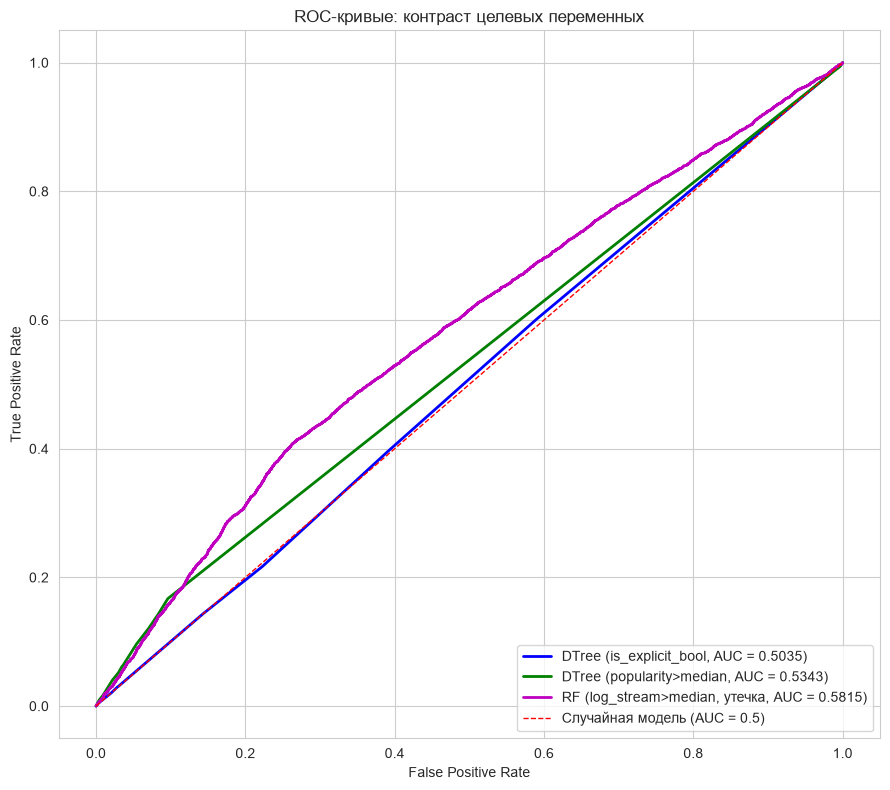

In [43]:
plt.figure(figsize=(9, 8))

plt.plot(fpr,     tpr,     'b-',  linewidth=2,
         label=f'DTree (is_explicit_bool, AUC = {auc_score:.4f})')
plt.plot(fpr_dt2, tpr_dt2, 'g-',  linewidth=2,
         label=f'DTree (popularity>median, AUC = {auc_dt2:.4f})')
plt.plot(fpr_demo, tpr_demo, 'm-', linewidth=2,
         label=f'RF (log_stream>median, утечка, AUC = {auc_demo:.4f})')
plt.plot([0, 1], [0, 1], 'r--', linewidth=1,
         label='Случайная модель (AUC = 0.5)')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривые: контраст целевых переменных')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

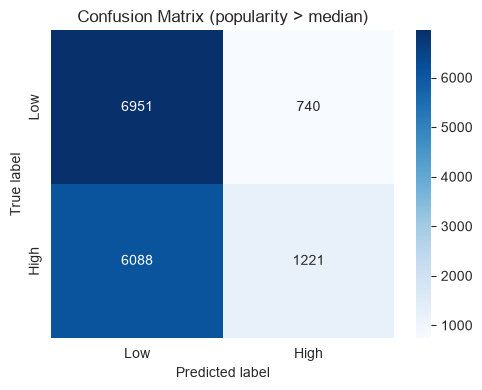

In [44]:
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test_c2, y_pred_clf2),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low', 'High'],
            yticklabels=['Low', 'High'])
plt.title('Confusion Matrix (popularity > median)')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()